## Implementation of PVD

In [29]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

In [30]:
img = Image.open(image_path)

from PIL import Image
import numpy as np


# -----------------------------
# Text to Binary
# -----------------------------
def text_to_binary(text):

    return ''.join(
        format(ord(c), '08b')
        for c in text
    )


# -----------------------------
# PVD Range Table
# -----------------------------
def get_range(diff):

    ranges = [
        (0, 7),
        (8, 15),
        (16, 31),
        (32, 63),
        (64, 127),
        (128, 255)
    ]

    for lower, upper in ranges:

        if lower <= diff <= upper:

            return lower, upper

    return None


# -----------------------------
# PVD Encoder
# -----------------------------
def encode_pvd(
        image_path,
        secret_message,
        output_path):

    img = Image.open(image_path)

    img_array = np.array(img)

    # Work only on Red channel
    flat = img_array[:, :, 0].flatten()

    binary_message = (
        text_to_binary(secret_message)
        + "1111111111111110"
    )

    capacity_bits = 0

    for i in range(
            0,
            len(flat)-1,
            2):

        p1 = int(flat[i])
        p2 = int(flat[i+1])

        d = abs(p1-p2)

        lower, upper = get_range(d)

        width = upper-lower+1

        capacity_bits += int(
            np.floor(
                np.log2(width)
            )
        )

    print("="*50)
    print("PVD CAPACITY ANALYSIS")
    print("="*50)

    print(
        "Total Capacity (bits):",
        capacity_bits
    )

    print(
        "Total Capacity (chars):",
        capacity_bits // 8
    )

    print(
        "Message Size (bits):",
        len(binary_message)
    )

    if len(binary_message) > capacity_bits:

        raise ValueError(
            "Message exceeds image capacity!"
        )

   
    bit_index = 0

    for i in range(
            0,
            len(flat)-1,
            2):

        if bit_index >= len(binary_message):

            break

        p1 = int(flat[i])
        p2 = int(flat[i+1])

        d = abs(p1-p2)

        lower, upper = get_range(d)

        width = upper-lower+1

        n_bits = int(
            np.floor(
                np.log2(width)
            )
        )

        # Remaining bits
        if bit_index+n_bits > len(binary_message):

            n_bits = (
                len(binary_message)
                - bit_index
            )

        bits = binary_message[
            bit_index:
            bit_index+n_bits
        ]

        value = int(bits, 2)

        new_diff = lower + value

        m = new_diff - d

        if p1 >= p2:

            p1 = p1 + int(
                np.ceil(m/2)
            )

            p2 = p2 - int(
                np.floor(m/2)
            )

        else:

            p1 = p1 - int(
                np.floor(m/2)
            )

            p2 = p2 + int(
                np.ceil(m/2)
            )

        p1 = np.clip(
            p1,
            0,
            255
        )

        p2 = np.clip(
            p2,
            0,
            255
        )

        flat[i] = p1
        flat[i+1] = p2

        bit_index += n_bits

    # --------------------------------
    # Reconstruct Image
    # --------------------------------
    stego_red = flat.reshape(
        img_array[:, :, 0].shape
    )

    result = img_array.copy()

    result[:, :, 0] = stego_red

    Image.fromarray(
        result.astype(np.uint8)
    ).save(output_path)


    modified_pixels = np.sum(
        img_array[:, :, 0]
        !=
        result[:, :, 0]
    )

    difference = np.abs(
        img_array[:, :, 0].astype(int)
        -
        result[:, :, 0].astype(int)
    )

    payload_utilization = (
        len(binary_message)
        /
        capacity_bits
    ) * 100

    print("\n")
    print("="*50)
    print("EMBEDDING STATISTICS")
    print("="*50)

    print(
        "Bits Embedded:",
        bit_index
    )

    print(
        "Modified Pixels:",
        modified_pixels
    )

    print(
        "Maximum Pixel Change:",
        np.max(difference)
    )

    print(
        "Average Pixel Change:",
        np.mean(difference)
    )

    print(
        f"Capacity Utilization: "
        f"{payload_utilization:.2f}%"
    )

    print("="*50)

    return img_array, result

In [31]:
## Parameters for chcking the performance

def mse(original, stego):

    return np.mean(
        (
            original.astype(float)
            -
            stego.astype(float)
        ) ** 2
    )

def psnr(original, stego):

    mse_val = mse(
        original,
        stego
    )

    if mse_val == 0:

        return float('inf')

    return 10 * np.log10(
        (255**2) /
        mse_val
    )

from skimage.metrics import structural_similarity as ssim

def calculate_ssim(
        original,
        stego):

    score, _ = ssim(
        original,
        stego,
        channel_axis=2,
        full=True
    )

    return score

In [ ]:
secret="Maybe its the way you say my name Maybe its the way you play your game But its goodI ve never known anybody like youBut its so good, Ive never dreamed of nobody like youAnd Ive heard of a love that comes once in a lifetimeAnd Im pretty sure "
original, stego = encode_pvd(
    "original.png",
    secret,
    "pvd_stego.png"
)

print("Message embedded successfully")

PVD CAPACITY ANALYSIS
Total Capacity (bits): 539505
Total Capacity (chars): 67438
Message Size (bits): 1944


EMBEDDING STATISTICS
Bits Embedded: 1944
Modified Pixels: 965
Maximum Pixel Change: 4
Average Pixel Change: 0.005567698487712666
Capacity Utilization: 0.36%
Message embedded successfully


In [33]:
mse_val = mse(
    original,
    stego
)

psnr_val = psnr(
    original,
    stego
)

ssim_val = calculate_ssim(
    original,
    stego
)

print("\nQUALITY METRICS")
print("="*50)

print("MSE :", mse_val)
print("PSNR:", psnr_val, "dB")
print("SSIM:", ssim_val)


QUALITY METRICS
MSE : 0.0043803166351606805
PSNR: 71.71574855858601 dB
SSIM: 0.9999851353547639


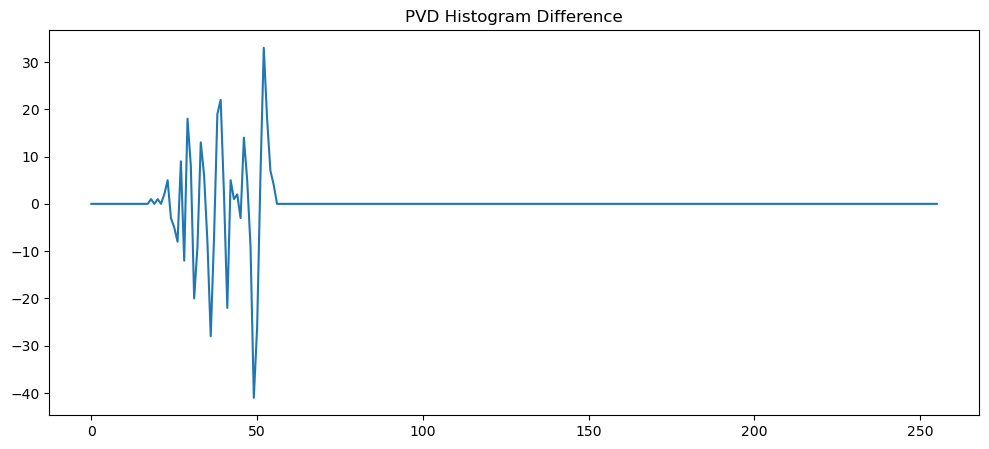

In [34]:
orig_hist,_ = np.histogram(
    original.flatten(),
    bins=256,
    range=(0,256)
)

stego_hist,_ = np.histogram(
    stego.flatten(),
    bins=256,
    range=(0,256)
)

plt.figure(figsize=(12,5))

plt.plot(
    stego_hist -
    orig_hist
)

plt.title(
    "PVD Histogram Difference"
)

plt.show()

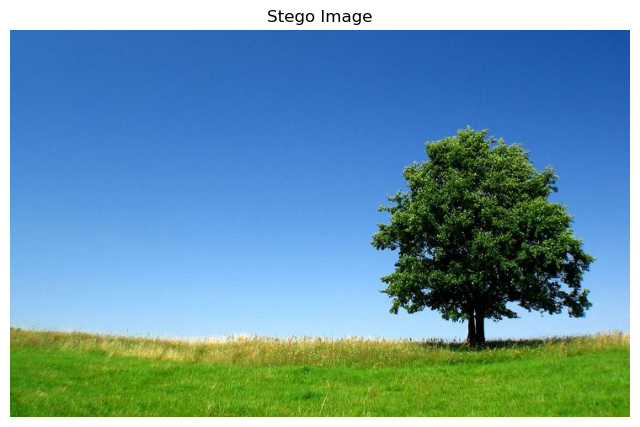

In [36]:
stego = Image.open("pvd_stego.png")

plt.figure(figsize=(8,8))
plt.imshow(stego)
plt.title("Stego Image")
plt.axis("off")
plt.show()

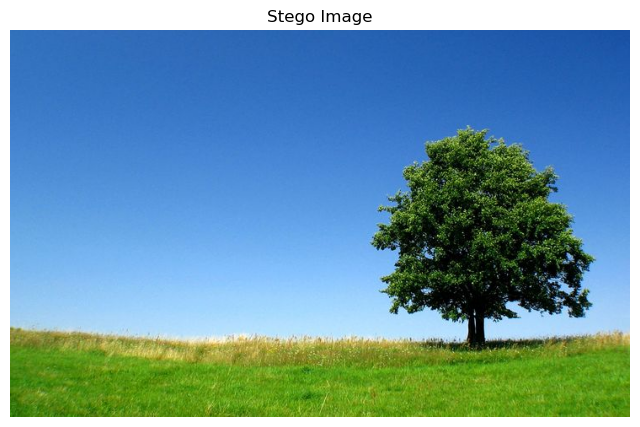

In [37]:
stego = Image.open("original1.png")

plt.figure(figsize=(8,8))
plt.imshow(stego)
plt.title("Stego Image")
plt.axis("off")
plt.show()